In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file
import pandas as pd
data = pd.read_csv(r"C:\Users\Disha\IISER - B Summer Internship\Brent Oil Futures Historical Data.csv")

In [3]:
# Print the first 5 rows of the dataset
print(data.head())

# Get a summary of the dataset
print(data.dtypes)

# Get summary statistics for numerical columns
print(data.describe())

         Date  Price   Open   High    Low     Vol. Change %
0  07/01/2019  65.06  65.05  66.75  64.22  361.41K   -2.24%
1  06/28/2019  66.55  66.51  66.84  66.08   34.62K    0.00%
2  06/27/2019  66.55  66.05  66.82  65.63  103.16K    0.09%
3  06/26/2019  66.49  65.80  66.85  65.60  141.95K    2.21%
4  06/25/2019  65.05  64.89  65.98  64.17  205.80K    0.29%
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.         object
Change %     object
dtype: object
             Price         Open         High          Low
count  5000.000000  5000.000000  5000.000000  5000.000000
mean     65.320384    65.318124    66.179498    64.419316
std      30.340801    30.326109    30.583107    30.042614
min      17.680000    17.400000    18.050000    16.650000
25%      40.245000    40.235000    40.967500    39.435000
50%      61.830000    61.795000    62.800000    60.920000
75%      87.440000    87.450000    88.725000    86.185000
max     146.080000   1

In [4]:
# Converting "Vol." column to float datatype
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


In [5]:
# Check for null values in each column
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        2
Change %    0
dtype: int64


In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


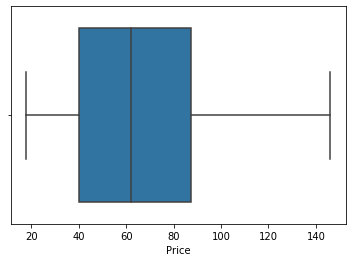

In [7]:
# Create a boxplot of a numerical column
sns.boxplot(data['Price'])
plt.show()

In [8]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

         Date  Price   Open   High    Low      Vol.
0  07/01/2019  65.06  65.05  66.75  64.22  361410.0
1  06/28/2019  66.55  66.51  66.84  66.08   34620.0
2  06/27/2019  66.55  66.05  66.82  65.63  103160.0
3  06/26/2019  66.49  65.80  66.85  65.60  141950.0
4  06/25/2019  65.05  64.89  65.98  64.17  205800.0


In [9]:
# Drop a column from the dataset
data = data.drop('Date', axis=1)

# Show the updated dataset
print(data.head())

   Price   Open   High    Low      Vol.
0  65.06  65.05  66.75  64.22  361410.0
1  66.55  66.51  66.84  66.08   34620.0
2  66.55  66.05  66.82  65.63  103160.0
3  66.49  65.80  66.85  65.60  141950.0
4  65.05  64.89  65.98  64.17  205800.0


In [10]:
# extract features and target
X = data[['Open', 'High', 'Low','Vol.']]
y = data['Price']

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into a 98/2 train/test split
train_X, test_X, train_y, test_y = train_test_split(data, y, test_size=0.02, random_state=42)

In [12]:
# Fitting Random Forest Regressor to the training set  
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Create a Random Forest Regressor
regressor = RandomForestRegressor(n_estimators=25, max_depth=5, random_state=42)

# Train the model using the training data
regressor.fit(train_X, train_y)

# Use the fitted model to make predictions on the test data
pred = regressor.predict(test_X)

# Calculate R-squared
r2 = r2_score(test_y,pred)
print(r2)

# Evaluate the model's performance
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, pred))
print("Root Mean Squared Error: ", rmse)

0.9994288572217509
Root Mean Squared Error:  0.6394829535111031


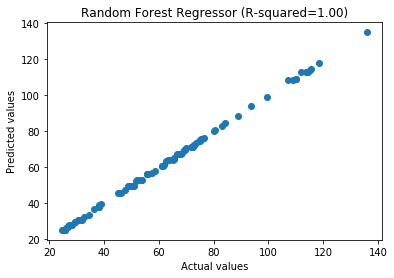

In [13]:
# Plot actual vs predicted values
plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Random Forest Regressor (R-squared={r2:.2f})")
plt.show()

In [14]:
# Gradient Boost
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the gradient boost regressor
gb = GradientBoostingRegressor()

# Fit the regressor to the training data
gb.fit(train_X, train_y)

# Make predictions on the test data
pred = gb.predict(test_X)

# Calculate R-squared
r2 = r2_score(test_y,pred)
print(r2)

# Evaluate the model's performance
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, pred))
print("Root Mean Squared Error: ", rmse)

0.9999269269243963
Root Mean Squared Error:  0.22873642058257607


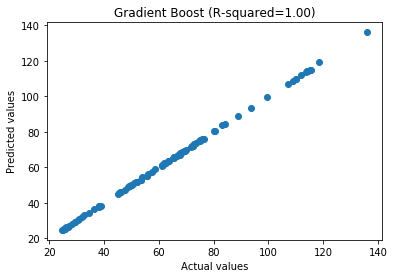

In [15]:
# Plot actual vs predicted values
plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Gradient Boost (R-squared={r2:.2f})")
plt.show()

In [16]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create an instance of DecisionTreeRegressor with max depth of 5
dt_regressor = DecisionTreeRegressor(max_depth=5)

# Fit the model on training data
dt_regressor.fit(train_X, train_y)

# Make predictions on test data
pred = dt_regressor.predict(test_X)

# Calculate R-squared
r2 = r2_score(test_y,pred)
print(r2)

# Evaluate the model's performance
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, pred))
print("Root Mean Squared Error: ", rmse)

0.9982744901073555
Root Mean Squared Error:  1.1115150667320726


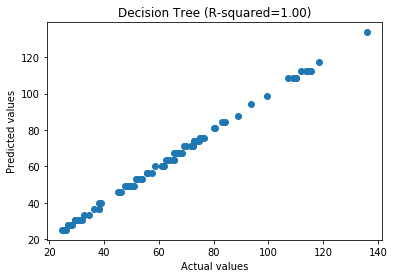

In [17]:
# Plot actual vs predicted values
plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Decision Tree (R-squared={r2:.2f})")
plt.show()

Ensemble Model

In [18]:
from sklearn.ensemble import VotingRegressor 

# Define the individual models
random_forest = RandomForestRegressor(n_estimators=800, max_depth=10, max_leaf_nodes=100)
decision_tree = DecisionTreeRegressor()

In [19]:
# Create the bagging ensemble
ensemble = VotingRegressor([('random_forest', random_forest), ('decision_tree', decision_tree)])

In [20]:
# Train the ensemble on the training data
ensemble.fit(train_X, train_y)

VotingRegressor(estimators=[('random_forest',
                             RandomForestRegressor(bootstrap=True,
                                                   ccp_alpha=0.0,
                                                   criterion='mse',
                                                   max_depth=10,
                                                   max_features='auto',
                                                   max_leaf_nodes=100,
                                                   max_samples=None,
                                                   min_impurity_decrease=0.0,
                                                   min_impurity_split=None,
                                                   min_samples_leaf=1,
                                                   min_samples_split=2,
                                                   min_weight_fraction_leaf=0.0,
                                                   n_estimators=800,
                             

In [21]:
# Make predictions using the ensemble
ensemble_preds = ensemble.predict(test_X)

In [22]:
# Evaluate the ensemble's performance

# Calculate R-squared
r2 = r2_score(test_y,ensemble_preds)
print(r2)

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, ensemble_preds))
print("Root Mean Squared Error: ", rmse)

0.9999969573837135
Root Mean Squared Error:  0.046674558655410786


In [23]:
# Gradient Boost Ensemble
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [24]:
# Define the individual models
gradient_boost_1 = GradientBoostingRegressor(n_estimators=400)
gradient_boost_2 = GradientBoostingRegressor(n_estimators=500)
gradient_boost_3 = GradientBoostingRegressor(n_estimators=600)

In [25]:
# Train the individual models on the training data
gradient_boost_1.fit(train_X, train_y)
gradient_boost_2.fit(train_X, train_y)
gradient_boost_3.fit(train_X, train_y)

GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0, criterion='friedman_mse',
                          init=None, learning_rate=0.1, loss='ls', max_depth=3,
                          max_features=None, max_leaf_nodes=None,
                          min_impurity_decrease=0.0, min_impurity_split=None,
                          min_samples_leaf=1, min_samples_split=2,
                          min_weight_fraction_leaf=0.0, n_estimators=600,
                          n_iter_no_change=None, presort='deprecated',
                          random_state=None, subsample=1.0, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

In [26]:
# Make predictions using the individual models
gb_1_preds = gradient_boost_1.predict(test_X)
gb_2_preds = gradient_boost_2.predict(test_X)
gb_3_preds = gradient_boost_3.predict(test_X)

In [27]:
# Evaluate the individual models

# Calculate R-squared
r2_1 = r2_score(test_y,gb_1_preds)
r2_2 = r2_score(test_y,gb_2_preds)
r2_3 = r2_score(test_y,gb_3_preds)

print(r2_1)
print(r2_2)
print(r2_3)

gb_1_rmse = mean_squared_error(test_y, gb_1_preds, squared=False)
gb_2_rmse = mean_squared_error(test_y, gb_2_preds, squared=False)
gb_3_rmse = mean_squared_error(test_y, gb_3_preds, squared=False)

print("Gradient Boost 1 RMSE:", gb_1_rmse)
print("Gradient Boost 2 RMSE:", gb_2_rmse)
print("Gradient Boost 3 RMSE:", gb_3_rmse)

0.9999739548700798
0.9999775655145023
0.9999807595897464
Gradient Boost 1 RMSE: 0.1365588627355832
Gradient Boost 2 RMSE: 0.12674028642518498
Gradient Boost 3 RMSE: 0.11737180711676608


In [28]:
# Create the voting ensemble
ensemble = VotingRegressor([('gradient_boost_1', gradient_boost_1),
                            ('gradient_boost_2', gradient_boost_2),
                            ('gradient_boost_3', gradient_boost_3)])

In [29]:
# Train the ensemble on the training data
ensemble.fit(train_X, train_y)

VotingRegressor(estimators=[('gradient_boost_1',
                             GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0,
                                                       criterion='friedman_mse',
                                                       init=None,
                                                       learning_rate=0.1,
                                                       loss='ls', max_depth=3,
                                                       max_features=None,
                                                       max_leaf_nodes=None,
                                                       min_impurity_decrease=0.0,
                                                       min_impurity_split=None,
                                                       min_samples_leaf=1,
                                                       min_samples_split=2,
                                                       min_weight_fraction_leaf=0.0,
                      

In [30]:
# Make predictions using the ensemble
ensemble_preds = ensemble.predict(test_X)

In [31]:
# Stacking Ensemble model
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [32]:
# Define the base models
gradient_boost_model = VotingRegressor([('gradient_boost_1', gradient_boost_1),
                                        ('gradient_boost_2', gradient_boost_2),
                                        ('gradient_boost_3', gradient_boost_3)])

bagging_model = VotingRegressor([('random_forest', regressor),
                                 ('decision_tree', dt_regressor)])

In [33]:
# Define the meta-model
meta_model = LinearRegression()

In [34]:
# Create the stacking ensemble
ensemble = StackingRegressor(estimators=[('gradient_boost', gradient_boost_model),
                                         ('bagging', bagging_model)],
                                          final_estimator=meta_model)

In [35]:
# Train the stacking ensemble on the training data
ensemble.fit(train_X, train_y)

StackingRegressor(cv=None,
                  estimators=[('gradient_boost',
                               VotingRegressor(estimators=[('gradient_boost_1',
                                                            GradientBoostingRegressor(alpha=0.9,
                                                                                      ccp_alpha=0.0,
                                                                                      criterion='friedman_mse',
                                                                                      init=None,
                                                                                      learning_rate=0.1,
                                                                                      loss='ls',
                                                                                      max_depth=3,
                                                                                      max_features=None,
                               

In [36]:
# Make predictions using the stacking ensemble
ensemble_preds = ensemble.predict(test_X)

In [37]:
# Evaluate the stacking ensemble
# Calculate R-squared
r2 = r2_score(test_y,ensemble_preds)
print(r2)

ensemble_rmse = mean_squared_error(test_y, ensemble_preds, squared=False) 
print("Ensemble RMSE:", ensemble_rmse)

0.9999776083641788
Ensemble RMSE: 0.1266191921406343


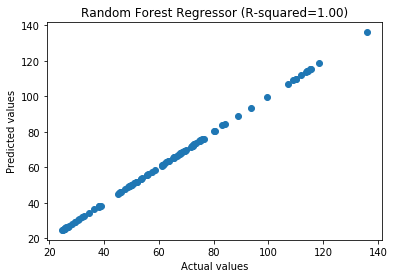

In [38]:
# Plot actual vs predicted values
plt.scatter(test_y, ensemble_preds)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Random Forest Regressor (R-squared={r2:.2f})")
plt.show()